# Data Visualization Project

Sam Harvan, Joaquin Rodriguez Landaeta, Ria Timm

This notebook aims to analyze data on scientific collaboration. It imports data that was optained from PubMed, cleaned and gendered using Genderize.io. 
It then analyzes team composition on papers in the areas of breast and prostate cancer.

# Import necessary libraries and data

### install dependencies for ffmpeg in the environment you're using.

In [1]:
from collections import Counter
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import plotly.io as pio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.animation as animation
import os
from graph_tool.all import load_graph, graph_draw, sfdp_layout, label_largest_component
from multiprocessing import Pool
from IPython.display import HTML

In [2]:
authors_df = pd.read_csv('authors_cleaned.csv')

In [3]:
authors_df

,PMID,DescriptorName_UI,LastName,ForeName,AID,ORCID,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year,Publication_Year,Century_Decade,Mention,author_name,Gender
0,11584014,D011471,Fujii,Teruhiko,6757189,NaN,NaN,2002,2002,2000-2010,prostate,Teruhiko Fujii,male
1,11584014,D011471,Wang,Qiming,5191708,NaN,NaN,2002,2002,2000-2010,prostate,Qiming Wang,male
2,11584014,D011471,Blumberg,Peter,3687806,NaN,NaN,2002,2002,2000-2010,prostate,Peter M Blumberg,male
3,11584014,D011471,Ohba,Motoi,8648208,NaN,NaN,2002,2002,2000-2010,prostate,Motoi Ohba,male
4,11584014,D011471,Kuroki,Toshio,2419118,NaN,NaN,2002,2002,2000-2010,prostate,Toshio Kuroki,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172605,28199152,D001943,Hargreaves,Jonathan,6375005,NaN,NaN,2017,2017,2011-2020,breast,Jonathan Hargreaves,male
1172606,28199152,D001943,Elson,Sarah,9419835,NaN,NaN,2017,2017,2011-2020,breast,Sarah L Elson,female
1172607,28199152,D001943,Joe,Bonnie,1351306,NaN,NaN,2017,2017,2011-2020,breast,Bonnie N Joe,female
1172608,28199152,D001943,Feig,Stephen,4908077,NaN,NaN,2017,2017,2011-2020,breast,Stephen A Feig,male


## Data pre-processing

We are removing all authors with less than 5 publications to remove noise from our data.

In [4]:
#filter data for authors with > 5 publications
authors_with_more_than_5 = authors_df.groupby('AID').size()[authors_df.groupby('AID').size() > 5].index #group by unique author id (AID) and count publications per author

#filter og data and clean
filtered_authors_df = authors_df[authors_df['AID'].isin(authors_with_more_than_5)]

In [5]:
filtered_authors_df

,PMID,DescriptorName_UI,LastName,ForeName,AID,ORCID,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year,Publication_Year,Century_Decade,Mention,author_name,Gender
0,11584014,D011471,Fujii,Teruhiko,6757189,NaN,NaN,2002,2002,2000-2010,prostate,Teruhiko Fujii,male
1,11584014,D011471,Wang,Qiming,5191708,NaN,NaN,2002,2002,2000-2010,prostate,Qiming Wang,male
2,11584014,D011471,Blumberg,Peter,3687806,NaN,NaN,2002,2002,2000-2010,prostate,Peter M Blumberg,male
6,11584014,D011471,Marquez,Victor,295253,NaN,NaN,2002,2002,2000-2010,prostate,Victor E Marquez,male
7,11584014,D011471,Kazanietz,Marcelo,1988542,NaN,NaN,2002,2002,2000-2010,prostate,Marcelo G Kazanietz,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172599,28199152,D001943,Wisner,Dorota,10374890,NaN,NaN,2017,2017,2011-2020,breast,Dorota J Wisner,female
1172602,28199152,D001943,Bassett,Lawrence,3408378,NaN,NaN,2017,2017,2011-2020,breast,Lawrence W Bassett,male
1172603,28199152,D001943,Ojeda-Fournier,Haydee,9480985,NaN,NaN,2017,2017,2011-2020,breast,Haydee Ojeda-Fournier,female
1172607,28199152,D001943,Joe,Bonnie,1351306,NaN,NaN,2017,2017,2011-2020,breast,Bonnie N Joe,female


# Fig 1: gender-ratio in fields

Our first figure shows the gender ratio of both fields. 

In [6]:
prostate_cancer = filtered_authors_df[(filtered_authors_df['Mention'] == 'prostate')] #separating the data for prostate cancer
breast_cancer = filtered_authors_df[filtered_authors_df['Mention'] == 'breast'] #separating the data for breast cancer

In [7]:
male_prostate_researchers = prostate_cancer[prostate_cancer['Gender'] == 'male']['AID'].nunique() #unique male prostate researchers
female_prostate_researchers = prostate_cancer[prostate_cancer['Gender'] == 'female']['AID'].nunique() #unique female prostate researchers
male_breast_researchers = breast_cancer[breast_cancer['Gender'] == 'male']['AID'].nunique() #unique male breast researchers
female_breast_researchers = breast_cancer[breast_cancer['Gender'] == 'female']['AID'].nunique() #unique female breast researchers

In [8]:
male_prostate_researchers

15211

In [9]:
print(breast_cancer['AID'].nunique())
print(prostate_cancer['AID'].nunique())

30351
22249


In [33]:
#set the renderer to browser because I'm working in VS Code
pio.renderers.default = "browser" 

data = []

#add data
data.append({"level1": "Breast Cancer", "level2": "Female Researchers", "value": female_breast_researchers})
data.append({"level1": "Prostate Cancer", "level2": "Male Researchers", "value": male_prostate_researchers})
data.append({"level1": "Prostate Cancer", "level2": "Female Researchers", "value": female_prostate_researchers})
data.append({"level1": "Breast Cancer", "level2": "Male Researchers", "value": male_breast_researchers})

df = pd.DataFrame(data)

#define colors
color_scale = {"Prostate Cancer": "#008000", "Breast Cancer": "#800080"}

print(df)

            level1              level2  value
0    Breast Cancer  Female Researchers  12531
1  Prostate Cancer    Male Researchers  15211
2  Prostate Cancer  Female Researchers   7268
3    Breast Cancer    Male Researchers  18481


In [34]:
#creat figure
fig = px.sunburst(
    df,
    path=['level1', 'level2'],
    values='value',
    color='level1',  
    color_discrete_map=color_scale,
    branchvalues='total',
    title="Gender Distribution of Cancer Researchers")

fig.update_traces(sort=False) #so that females are next to females

fig.update_layout(
    width=800,
    height=800,
    margin=dict(l=20, r=20, t=50, b=20),
    font=dict(size=18)
)

#save output
output_file = "researcher_sunburst_chart.html"
fig.write_html(output_file)
print(f"Chart saved to {output_file}")

fig.show()

Chart saved to researcher_sunburst_chart.html


Interpretation: In Figure 1, there are noticeable gender differences in prostate and breast cancer research. Breast cancer is a larger research field overall. In both fields, male researchers are more prevalent, though the disparity is more pronounced in prostate cancer research.

# Fig 2: team composition in fields

In [10]:
years = authors_df['Publication_Year'].unique()

#classify team compositions
def classify_team(genders):
    gender_counts = Counter(genders)
    if gender_counts.get('male', 0) > 0 and gender_counts.get('female', 0) > 0:
        return 'mixed-gender'
    elif gender_counts.get('male', 0) > 0:
        return 'male-only'
    elif gender_counts.get('female', 0) > 0:
        return 'female-only'
    else:
        return 'unknown'

def teams_analysis(df):
    year_results = {}

    for year in years:
        year_df = df[df['Publication_Year'] == year]

        teams = year_df.groupby('PMID')['Gender'].apply(list) #group by PMID for teams

        team_composition = teams.apply(classify_team) #count gender of team members

        composition_counts = team_composition.value_counts() #count number of papers with each team composition

        total_teams = composition_counts.sum()
        composition_percentages = (composition_counts / total_teams) * 100

        year_results[year] = {
            'counts': composition_counts,
            'percentages': composition_percentages
        }
    return year_results

## prostate

In [11]:
teams_prostate = prostate_cancer.groupby('PMID')['Gender'].apply(list) #group by PMID for teams

team_composition_prostate = teams_prostate.apply(classify_team) 

composition_counts_prostate = team_composition_prostate.value_counts() #count number of papers with each team composition

total_teams = composition_counts_prostate.sum()
composition_percentages_prostate = (composition_counts_prostate / total_teams) * 100

print("Composition Counts:")
print(composition_counts_prostate)

print("\nComposition Percentages:")
for category, percentage in composition_percentages_prostate.items():
    print(f"{category.capitalize()}: {percentage:.2f}%")

Composition Counts:
Gender
male-only       33254
mixed-gender    24906
female-only      4780
Name: count, dtype: int64

Composition Percentages:
Male-only: 52.83%
Mixed-gender: 39.57%
Female-only: 7.59%


## breast

In [12]:
teams_breast = breast_cancer.groupby('PMID')['Gender'].apply(list) #group by PMID for teams

team_composition_breast = teams_breast.apply(classify_team)

composition_counts_breast = team_composition_breast.value_counts() #count number of papers with each team composition

total_teams = composition_counts_breast.sum()
composition_percentages_breast = (composition_counts_breast / total_teams) * 100

print("Composition Counts:")
print(composition_counts_breast)

print("\nComposition Percentages:")
for category, percentage in composition_percentages_breast.items():
    print(f"{category.capitalize()}: {percentage:.2f}%")

Composition Counts:
Gender
mixed-gender    53234
male-only       41695
female-only     21170
Name: count, dtype: int64

Composition Percentages:
Mixed-gender: 45.85%
Male-only: 35.91%
Female-only: 18.23%


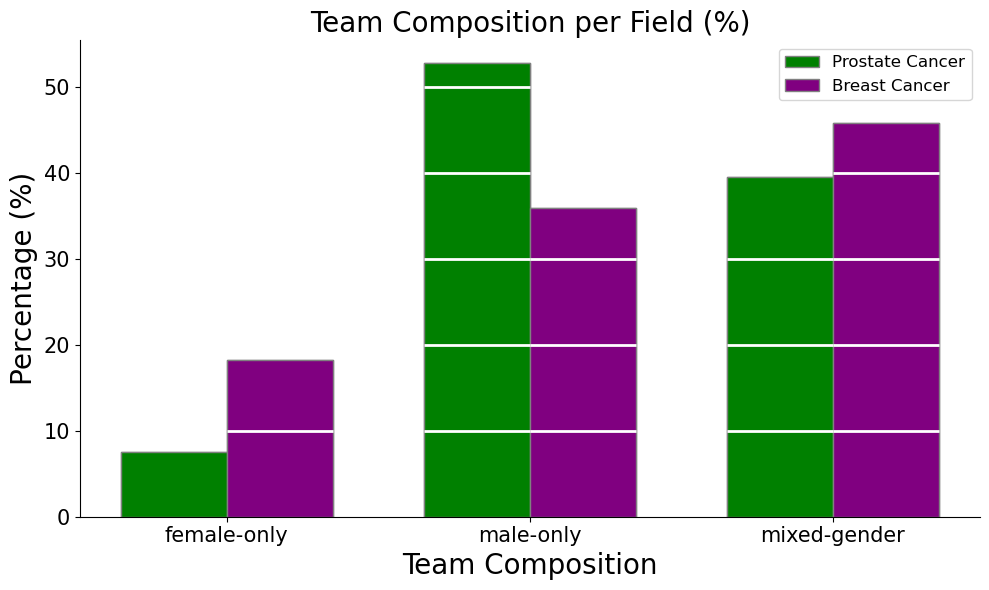

In [13]:
df = pd.DataFrame({'Prostate Cancer': composition_percentages_prostate, 'Breast Cancer': composition_percentages_breast}) #combine to df


bar_width = 0.35

#pos of bars
r1 = np.arange(len(df))
r2 = [x + bar_width for x in r1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(r1, df['Prostate Cancer'], color='green', width=bar_width, edgecolor='grey', label='Prostate Cancer')
ax.bar(r2, df['Breast Cancer'], color='purple', width=bar_width, edgecolor='grey', label='Breast Cancer')

ax.set_xlabel('Team Composition', fontsize=20)
ax.set_xticks([r + bar_width/2 for r in range(len(df))]) #xticks on the middle of the group bars
ax.set_xticklabels(df.index, fontsize=20)
ax.set_ylabel('Percentage (%)', fontsize=20)
ax.set_title('Team Composition per Field (%)', fontsize=20)
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)

#legend
ax.legend(fontsize=12)

#gridlines
#ax.grid(axis='y', linestyle='--')
bars1 = ax.bar(r1, df['Prostate Cancer'], color='green', width=bar_width, edgecolor='grey', label='Prostate Cancer')
bars2 = ax.bar(r2, df['Breast Cancer'], color='purple', width=bar_width, edgecolor='grey', label='Breast Cancer')

# Draw white horizontal lines inside each bar
tick_spacing = 10  
for bars in [bars1, bars2]:
    for bar in bars:
        x_start = bar.get_x()
        x_end = x_start + bar.get_width()
        y_max = bar.get_height()

        for y in range(tick_spacing, int(y_max), tick_spacing):
            ax.hlines(y, x_start, x_end, color='white', linewidth=2)

#delete spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('barplot_teams.png', dpi=600)
plt.show()


Interpretation: Figure 2 highlights the gender composition of research teams. Prostate cancer research has noticeably more male-only teams, whereas breast cancer research has a higher number of female-only teams. However, mixed-gender teams do not show significant differences between fields.

# Fig 3: Team composition over time

## prostate

In [14]:
teams_prostate = teams_analysis(prostate_cancer)

In [15]:
teams_prostate

{np.int64(2002): {'counts': Gender
  male-only       1279
  mixed-gender     637
  female-only      125
  Name: count, dtype: int64,
  'percentages': Gender
  male-only       62.665360
  mixed-gender    31.210191
  female-only      6.124449
  Name: count, dtype: float64},
 np.int64(2003): {'counts': Gender
  male-only       1457
  mixed-gender     779
  female-only      163
  Name: count, dtype: int64,
  'percentages': Gender
  male-only       60.733639
  mixed-gender    32.471863
  female-only      6.794498
  Name: count, dtype: float64},
 np.int64(2004): {'counts': Gender
  male-only       1519
  mixed-gender     963
  female-only      194
  Name: count, dtype: int64,
  'percentages': Gender
  male-only       56.763827
  mixed-gender    35.986547
  female-only      7.249626
  Name: count, dtype: float64},
 np.int64(2005): {'counts': Gender
  male-only       1699
  mixed-gender    1021
  female-only      189
  Name: count, dtype: int64,
  'percentages': Gender
  male-only       58.404

In [16]:
#extracting the data
data_percentages = {}

for year in years:
    if year in teams_prostate:  #some years are missing
        percentages = teams_prostate[year]['percentages']
        for category in percentages.index:
            if year not in data_percentages:
                data_percentages[year] = {}
            data_percentages[year][category] = percentages[category]

#to df and fill NaNs
data_percentages = {int(year): values for year, values in data_percentages.items()}
df_percentages_prostate = pd.DataFrame.from_dict(data_percentages, orient='index').fillna(0).sort_index() #sort by year

In [17]:
df_percentages_prostate

,male-only,mixed-gender,female-only
2002,62.665360,31.210191,6.124449
2003,60.733639,32.471863,6.794498
2004,56.763827,35.986547,7.249626
2005,58.404950,35.097972,6.497078
2006,55.566700,37.345369,7.087930
2007,54.067696,38.895487,7.036817
2008,52.615755,40.889958,6.494287
2009,52.461899,40.416178,7.121923
2010,52.059925,41.054451,6.885624
2011,53.429027,39.287613,7.283360


## breast

In [18]:
teams_breast = teams_analysis(breast_cancer)

In [19]:
teams_breast

{np.int64(2002): {'counts': Gender
  male-only       1763
  mixed-gender    1402
  female-only      657
  Name: count, dtype: int64,
  'percentages': Gender
  male-only       46.127682
  mixed-gender    36.682365
  female-only     17.189953
  Name: count, dtype: float64},
 np.int64(2003): {'counts': Gender
  male-only       1874
  mixed-gender    1608
  female-only      771
  Name: count, dtype: int64,
  'percentages': Gender
  male-only       44.063014
  mixed-gender    37.808606
  female-only     18.128380
  Name: count, dtype: float64},
 np.int64(2004): {'counts': Gender
  male-only       1907
  mixed-gender    1844
  female-only      762
  Name: count, dtype: int64,
  'percentages': Gender
  male-only       42.255706
  mixed-gender    40.859739
  female-only     16.884556
  Name: count, dtype: float64},
 np.int64(2005): {'counts': Gender
  mixed-gender    2230
  male-only       1983
  female-only      854
  Name: count, dtype: int64,
  'percentages': Gender
  mixed-gender    44.010

In [20]:
#extract data
data_percentages = {}

for year in years:
    if year in teams_breast:  #some years are missing
        percentages = teams_breast[year]['percentages']
        for category in percentages.index:
            if year not in data_percentages:
                data_percentages[year] = {}
            data_percentages[year][category] = percentages[category]  

#to df and fill NaNs
data_percentages = {int(year): values for year, values in data_percentages.items()}
df_percentages_breast = pd.DataFrame.from_dict(data_percentages, orient='index').fillna(0).sort_index() #sort by year

In [21]:
df_percentages_breast

,male-only,mixed-gender,female-only
2002,46.127682,36.682365,17.189953
2003,44.063014,37.808606,18.128380
2004,42.255706,40.859739,16.884556
2005,39.135583,44.010262,16.854154
2006,37.878788,46.029919,16.091293
2007,37.205449,45.986745,16.807806
2008,37.055153,46.230393,16.714454
2009,35.969806,46.340663,17.689531
2010,35.931700,45.998515,18.069785
2011,35.679750,46.914107,17.406143


In [22]:
merged_df = df_percentages_breast.merge(df_percentages_prostate, left_index=True, right_index=True, how='outer', suffixes=('_breast', '_prostate')) #merging both on the index

In [23]:
merged_df

,male-only_breast,mixed-gender_breast,female-only_breast,male-only_prostate,mixed-gender_prostate,female-only_prostate
2002,46.127682,36.682365,17.189953,62.665360,31.210191,6.124449
2003,44.063014,37.808606,18.128380,60.733639,32.471863,6.794498
2004,42.255706,40.859739,16.884556,56.763827,35.986547,7.249626
2005,39.135583,44.010262,16.854154,58.404950,35.097972,6.497078
2006,37.878788,46.029919,16.091293,55.566700,37.345369,7.087930
2007,37.205449,45.986745,16.807806,54.067696,38.895487,7.036817
2008,37.055153,46.230393,16.714454,52.615755,40.889958,6.494287
2009,35.969806,46.340663,17.689531,52.461899,40.416178,7.121923
2010,35.931700,45.998515,18.069785,52.059925,41.054451,6.885624
2011,35.679750,46.914107,17.406143,53.429027,39.287613,7.283360


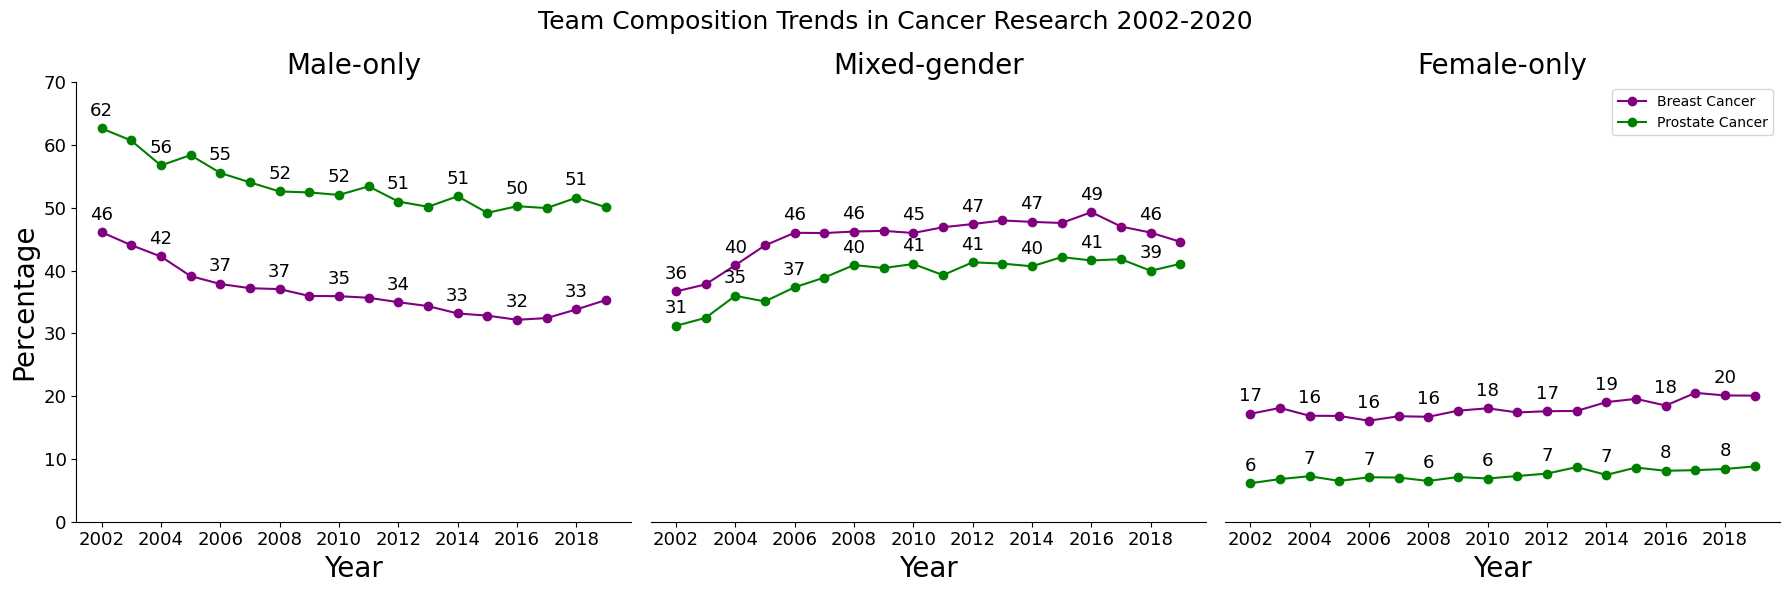

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#large text
label_size = 20
title_size = 20
tick_size = 13

#male-only
axes[0].plot(merged_df.index, merged_df['male-only_breast'], label='Breast Cancer', color='purple', marker='o')
axes[0].plot(merged_df.index, merged_df['male-only_prostate'], label='Prostate Cancer', color='green', marker='o')
axes[0].set_title('Male-only', fontsize=title_size)
axes[0].set_xlabel('Year', fontsize=label_size)
axes[0].set_ylabel('Percentage', fontsize=label_size)
axes[0].set_xticks(merged_df.index[::2])
axes[0].set_ylim(0, 70)
axes[0].tick_params(axis='both', labelsize=tick_size)

#remove spines (apart from y axis)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

#add numbers for every second point
for i in range(0, len(merged_df), 2):
    axes[0].text(merged_df.index[i], merged_df['male-only_breast'].iloc[i] + 2, 
                 str(int(merged_df['male-only_breast'].iloc[i])), ha='center', fontsize=tick_size)
    axes[0].text(merged_df.index[i], merged_df['male-only_prostate'].iloc[i] + 2, 
                 str(int(merged_df['male-only_prostate'].iloc[i])), ha='center', fontsize=tick_size)

#mixed-gender
axes[1].plot(merged_df.index, merged_df['mixed-gender_breast'], label='Breast Cancer', color='purple', marker='o')
axes[1].plot(merged_df.index, merged_df['mixed-gender_prostate'], label='Prostate Cancer', color='green', marker='o')
axes[1].set_title('Mixed-gender', fontsize=title_size)
axes[1].set_xlabel('Year', fontsize=label_size)
axes[1].set_xticks(merged_df.index[::2])
axes[1].set_ylim(0, 70)
axes[1].tick_params(axis='both', labelsize=tick_size)

#remove spines and y-axis
for spine in ['top', 'right', 'left']:
    axes[1].spines[spine].set_visible(False)
axes[1].tick_params(left=False, labelleft=False)

#add numbers for every second point
for i in range(0, len(merged_df), 2):
    axes[1].text(merged_df.index[i], merged_df['mixed-gender_breast'].iloc[i] + 2, 
                 str(int(merged_df['mixed-gender_breast'].iloc[i])), ha='center', fontsize=tick_size)
    axes[1].text(merged_df.index[i], merged_df['mixed-gender_prostate'].iloc[i] + 2, 
                 str(int(merged_df['mixed-gender_prostate'].iloc[i])), ha='center', fontsize=tick_size)

#female-only
axes[2].plot(merged_df.index, merged_df['female-only_breast'], label='Breast Cancer', color='purple', marker='o')
axes[2].plot(merged_df.index, merged_df['female-only_prostate'], label='Prostate Cancer', color='green', marker='o')
axes[2].set_title('Female-only', fontsize=title_size)
axes[2].set_xlabel('Year', fontsize=label_size)
axes[2].set_xticks(merged_df.index[::2])
axes[2].set_ylim(0, 70)
axes[2].tick_params(axis='both', labelsize=tick_size)
axes[2].legend()

#remove spines and y-axis
for spine in ['top', 'right', 'left']:
    axes[2].spines[spine].set_visible(False)

axes[2].tick_params(left=False, labelleft=False)

#add numbers for every second point
for i in range(0, len(merged_df), 2):
    axes[2].text(merged_df.index[i], merged_df['female-only_breast'].iloc[i] + 2, 
                 str(int(merged_df['female-only_breast'].iloc[i])), ha='center', fontsize=tick_size)
    axes[2].text(merged_df.index[i], merged_df['female-only_prostate'].iloc[i] + 2, 
                 str(int(merged_df['female-only_prostate'].iloc[i])), ha='center', fontsize=tick_size)

fig.suptitle('Team Composition Trends in Cancer Research 2002-2020', fontsize=18)
plt.tight_layout()
plt.savefig('lineplot_teams.png', dpi=600)
plt.show()


Interpretation: Figure 3 illustrates trends over time. The proportion of male-only teams has been decreasing, while mixed-gender teams have been gradually increasing. Female-only teams have remained relatively stable, with a slight upward trend.

# Animated Networks for all Years

In [67]:
# Variable definition
# Years to animate
years = list(range(2002, 2004))

# Directory for frames
frame_dir = "frames"
os.makedirs(frame_dir, exist_ok=True)

In [68]:
def render_frame(year):
    cancer = 'D001943' #breast
            #'D011471'  prostate
    g = load_graph(f"network_{cancer}_{year}.graphml.xml")

    # Keep only the largest component
    comp = label_largest_component(g)
    g.set_vertex_filter(comp)
    g.purge_vertices()

    # Use edge weights if available
    weights = g.ep["e_weight"] if "e_weight" in g.ep else None

    # Compute layout, accounts for weights and n of edges
    pos = sfdp_layout(g, eweight=weights)

    # Gender-based coloring
    gender_raw = g.vp["Gender"] if "Gender" in g.vp else None
    gender_color = g.new_vertex_property("vector<double>")
    gender_map = {
        "male": [0.5, 0, 1, 1], # blueberry
        "female":  [1.0, 0.5, 0.0, 1.0] # orange
    }
    for v in g.vertices():
        gender = gender_raw[v] if gender_raw else None
        gender_color[v] = gender_map.get(gender, [0.5, 0.5, 0.5, 1.0])

    frame_path = os.path.join(frame_dir, f"frame_{year}.png")
    graph_draw(
        g,
        pos=pos,
        vertex_fill_color=gender_color,
        vertex_font_size=10,
        output=frame_path,
        output_size=(600, 600),
    )
    return frame_path

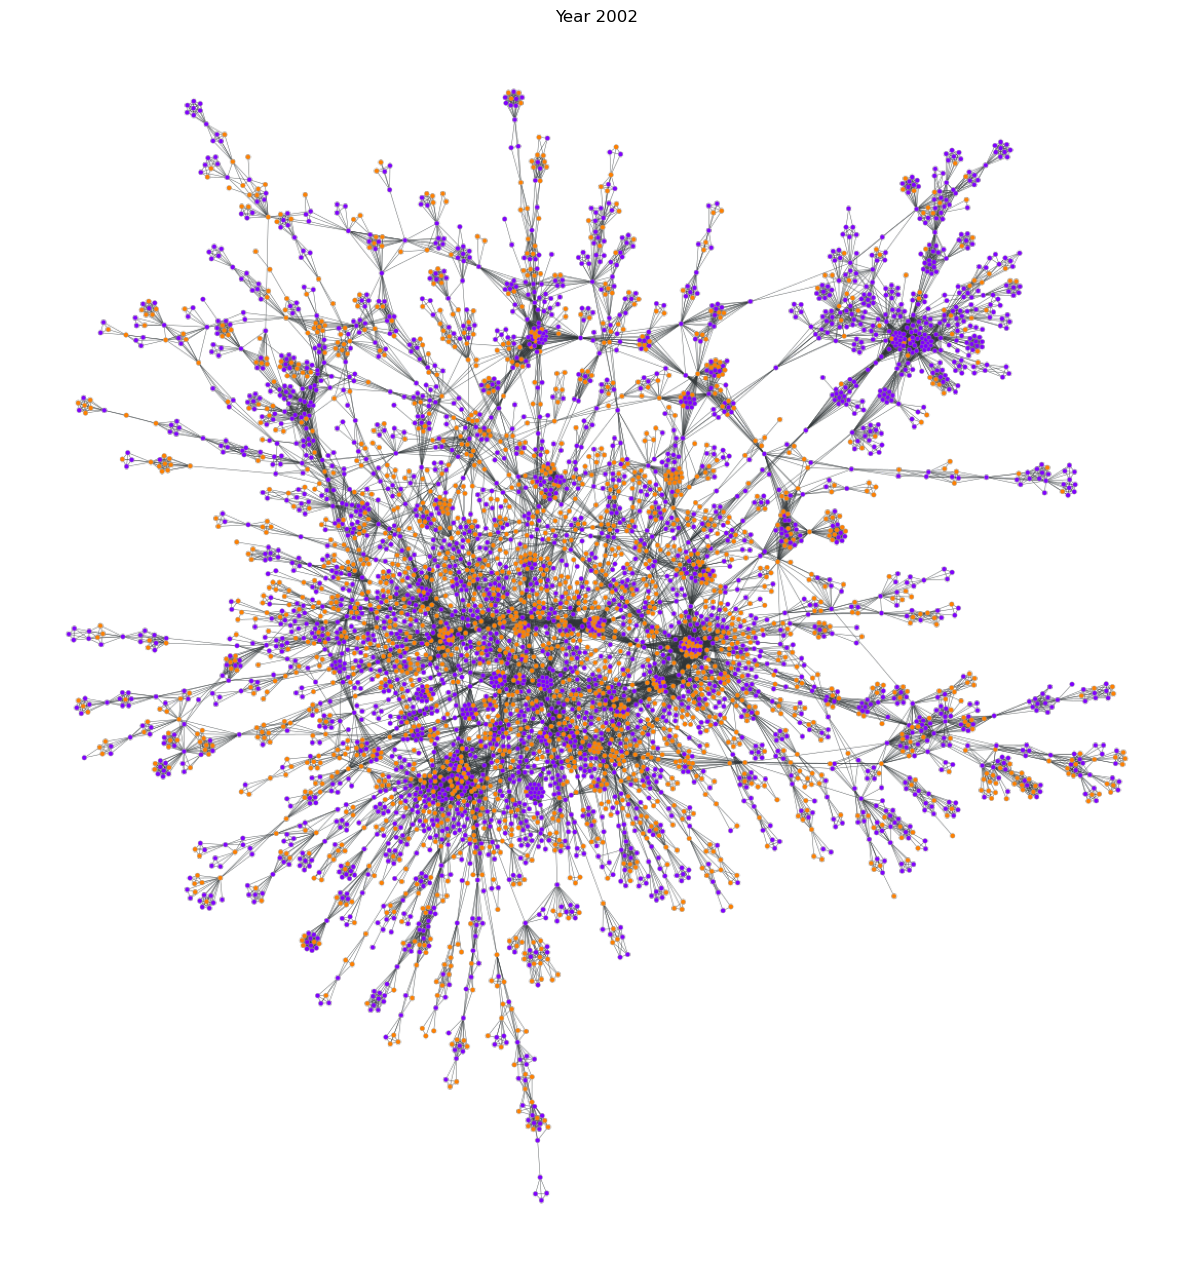

: 

In [ ]:
# Serial rendering of frames
frame_paths = []
for year in years:
    path = render_frame(year)
    frame_paths.append(path)

# Create animation
fig, ax = plt.subplots(figsize=(16, 16))

def animate(i):
    ax.clear()
    img = mpimg.imread(frame_paths[i])
    ax.imshow(img)
    ax.set_title(f"Year {years[i]}")
    ax.axis('off')

anim = animation.FuncAnimation(fig, animate, frames=len(frame_paths), interval=1000, blit=False)

# Show animation in notebook
HTML(anim.to_html5_video())